# Training simple GNN model

In [1]:
import torch
from torch.optim import Adam
import torch.nn.functional as F
from tqdm.auto import trange
import numpy as np
import matplotlib.pyplot as plt
from dgl.dataloading import GraphDataLoader
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning import Trainer
import pandas as pd
import dgl

from gnncloudmanufacturing.data import sample_dataset
from gnncloudmanufacturing.validation import check_feasibility, total_cost_from_gamma
from gnncloudmanufacturing.utils import (
    graph_from_problem, os_type, ss_type, GraphDataset, gamma_from_target, delta_from_gamma)
from gnncloudmanufacturing.graph_model import MLP

In [2]:
def prepare_train_val_dataset(n_tasks, n_operations, n_cities):
    dirpath = dirpath = f'train_data/{n_tasks}-{n_operations}-{n_cities}/'
    dataset = sample_dataset(
        100, 
        [n_tasks, n_tasks],
        [n_operations, n_operations],
        [n_cities, n_cities],
        threshold=0.2,
        dirpath=dirpath,
        random_seed=0
    )
    train_dataset = dataset[:80]
    val_dataset = dataset[80:]
    return train_dataset, val_dataset

def check_feasibility_dataset(dataset, n_tasks, n_operations, n_cities):
    average_cost = 0
    for problem in dataset:
        name = problem['name']
        delta = np.load(f'train_data/{n_tasks}-{n_operations}-{n_cities}/{name}/delta.npy')
        gamma = np.load(f'train_data/{n_tasks}-{n_operations}-{n_cities}/{name}/gamma.npy')
        check_feasibility(gamma, delta, problem)
        total_cost = total_cost_from_gamma(problem, gamma, delta)
        average_cost += total_cost
    average_cost = average_cost / len(dataset)
    print(f'Average cost: {average_cost:.2f}')

def prepare_graphs(dataset, n_tasks, n_operations, n_cities):
    graphs = []
    for problem in dataset:
        name = problem['name']
        gamma = np.load(f'train_data/{n_tasks}-{n_operations}-{n_cities}/{name}/gamma.npy')
        graph = graph_from_problem(problem, gamma, max_operations=n_operations)
        graph.edata['feat'][os_type][:, 0] /= 10
        graph.edata['feat'][ss_type][:] /= 100
        graphs.append(graph)
    return graphs

def plot_loss(trainer):
    metrics = pd.read_csv(f'lightning_logs/version_{trainer.logger.version}/metrics.csv')
    plt.plot(metrics.train_loss.dropna(), label='train loss')
    plt.plot(metrics.val_loss.dropna(), label='val loss')
    plt.legend()
    plt.title(f'Version {trainer.logger.version}')
    plt.show()

def print_pred_cost(model, dataset, n_operations):
    average_cost = 0
    for problem in dataset:
        name = problem['name']
        graph = graph_from_problem(problem, max_operations=n_operations)
        graph.edata['feat'][os_type][:, 0] /= 10
        graph.edata['feat'][ss_type][:] /= 100
        pred = model.predict(graph)
        gamma = gamma_from_target(pred, graph, problem)
        delta = delta_from_gamma(problem, gamma)
        check_feasibility(gamma, delta, problem)
        total_cost = total_cost_from_gamma(problem, gamma, delta)
        average_cost += total_cost
        print(f'Problem {problem["name"]}: {total_cost:.2f}')
    average_cost = average_cost / len(dataset)
    print(f'Average cost: {average_cost:.2f}')

## Model 10-10-10

In [3]:
n_tasks, n_operations, n_cities = 10, 10, 10
train_dataset, val_dataset = prepare_train_val_dataset(n_tasks, n_operations, n_cities)

In [4]:
check_feasibility_dataset(train_dataset, n_tasks, n_operations, n_cities)

Average cost: 15413.77


In [5]:
check_feasibility_dataset(val_dataset, n_tasks, n_operations, n_cities)

Average cost: 15464.60


In [6]:
train_graphs = prepare_graphs(train_dataset, n_tasks, n_operations, n_cities)
val_graphs = prepare_graphs(val_dataset, n_tasks, n_operations, n_cities)

train_graph_dataset = GraphDataset(train_graphs)
val_graph_dataset = GraphDataset(val_graphs)

train_dataloader = GraphDataLoader(train_graph_dataset, batch_size=8, shuffle=True)
val_dataloader = GraphDataLoader(val_graph_dataset, batch_size=100)

In [10]:
model = MLP(
    ins_dim=1,
    ino_dim=n_operations,
    out_dim=32,
    n_layers=3,
    lr=0.002,
)
model

MLP(
  (convs): ModuleList(
    (0): LinearLayer(
      (W_s): Linear(in_features=1, out_features=32, bias=True)
      (W_self): Linear(in_features=10, out_features=32, bias=True)
    )
    (1-2): 2 x LinearLayer(
      (W_s): Linear(in_features=32, out_features=32, bias=True)
      (W_self): Linear(in_features=32, out_features=32, bias=True)
    )
  )
  (dropout): Dropout(p=0.0, inplace=False)
  (dec): DotProductDecoder()
)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | convs   | ModuleList        | 4.6 K  | train
1 | dropout | Dropout           | 0      | train
2 | dec     | DotProductDecoder | 0      | train
------------------------------------------------------
4.6 K     Trainable params
0         Non-trainable params
4.6 K     Total params
0.019     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                           |…

/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |                                                                                                  |…

Validation: |                                                                                                |…

...

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

`Trainer.fit` stopped: `max_epochs=200` reached.


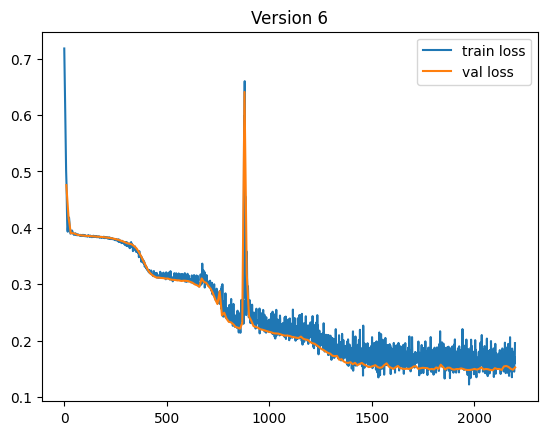

In [11]:
trainer = Trainer(
    enable_progress_bar=True,
    max_epochs=200,
    log_every_n_steps=1,
    logger=CSVLogger('.'),
    accelerator='cpu',
)
trainer.fit(
    model=model, 
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)
plot_loss(trainer)

In [12]:
print_pred_cost(model, val_dataset, n_operations)

Problem 10,10,10-81: 33166.67
Problem 10,10,10-82: 27818.84
Problem 10,10,10-83: 26262.32
Problem 10,10,10-84: 27696.50
Problem 10,10,10-85: 33849.78
Problem 10,10,10-86: 31405.55
Problem 10,10,10-87: 29186.42
Problem 10,10,10-88: 27282.61
Problem 10,10,10-89: 24215.01
Problem 10,10,10-90: 25713.13
Problem 10,10,10-91: 25928.23
Problem 10,10,10-92: 23909.01
Problem 10,10,10-93: 26443.35
Problem 10,10,10-94: 26720.15
Problem 10,10,10-95: 30528.08
Problem 10,10,10-96: 28916.82
Problem 10,10,10-97: 26043.44
Problem 10,10,10-98: 27746.63
Problem 10,10,10-99: 29682.09
Problem 10,10,10-100: 29176.08
Average cost: 28084.54
